# Etapa 2 — MLP PyTorch vs. Baselines

> **Tech Challenge — Telco Customer Churn Prediction**  
> Etapa 2: Modelagem com Redes Neurais (Disciplina 02)

Este notebook usa os módulos em `src/` como motor. Para adicionar um novo modelo, basta registrá-lo em `src/models/registry.py`.

**Entregável:** tabela comparativa de modelos + MLP treinado + artefatos no MLflow.

## 0. Setup — path do projeto

In [1]:
import os
import sys
from pathlib import Path

# Encontra a raiz do projeto (contém pyproject.toml)
def _find_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return start

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Muda o CWD para a raiz — garante que mlruns.db fique sempre lá
os.chdir(ROOT)
print(f"Project root : {ROOT}")
print(f"CWD          : {Path.cwd()}")

Project root : c:\Users\cecil\Tech-challenge-step-1\Tech-challenge-step-1
CWD          : c:\Users\cecil\Tech-challenge-step-1\Tech-challenge-step-1


## 1. Imports e logging

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import mlflow
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Módulos do projeto
from src.config import DataConfig, MLPConfig, MLflowConfig, setup_logging
from src.data.loader import ChurnDataLoader
from src.models.registry import MODEL_REGISTRY, PYTORCH_REGISTRY
from src.models.trainer import SklearnTrainer, compute_metrics
from src.models.mlp_trainer import PyTorchMLPTrainer
from src.service.mlflow_service import MLflowService

setup_logging("INFO")

print(f"PyTorch  : {torch.__version__}")
print(f"MLflow   : {mlflow.__version__}")
print(f"Modelos disponíveis no registry: {list(MODEL_REGISTRY.keys())}")

PyTorch  : 2.12.0+cpu
MLflow   : 3.12.0
Modelos disponíveis no registry: ['dummy', 'logistic_regression', 'ridge', 'decision_tree', 'random_forest', 'mlp_sklearn', 'catboost', 'xgboost']


## 2. Configuração do experimento

Altere apenas aqui para trocar dataset, modelos ou métricas.

In [3]:
data_cfg = DataConfig()

mlp_cfg = MLPConfig(
    hidden_sizes=[128, 64, 32],
    dropout_rates=[0.3, 0.2, 0.0],
    epochs=100,
    batch_size=256,
    learning_rate=1e-3,
    early_stopping_patience=10,
)

mlflow_cfg = MLflowConfig(experiment_name="telco-churn-etapa2")

# Modelos sklearn a rodar (subconjunto do registry ou todos)
SKLEARN_MODELS = list(MODEL_REGISTRY.keys())
RUN_PYTORCH = True

print(f"Dataset          : {data_cfg.path}")
print(f"Target           : {data_cfg.target}")
print(f"Tracking URI     : {mlflow_cfg.tracking_uri}")
print(f"Experimento      : {mlflow_cfg.experiment_name}")
print(f"Sklearn models   : {SKLEARN_MODELS}")

Dataset          : c:\Users\cecil\Tech-challenge-step-1\Tech-challenge-step-1\src\data\churn.csv
Target           : Churn
Tracking URI     : sqlite:///mlruns.db
Experimento      : telco-churn-etapa2
Sklearn models   : ['dummy', 'logistic_regression', 'ridge', 'decision_tree', 'random_forest', 'mlp_sklearn', 'catboost', 'xgboost']


## 3. Carregamento e pré-processamento dos dados

In [4]:
loader = ChurnDataLoader(
    path=data_cfg.path,
    target=data_cfg.target,
    test_size=data_cfg.test_size,
    random_state=data_cfg.random_state,
)

df = loader.load()
X_train, X_test, y_train, y_test, preprocessor = loader.get_splits(df)
dataset_info = loader.dataset_info()

print(f"\nDataset hash (SHA-256 prefix): {dataset_info['sha256']}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Churn rate — train: {y_train.mean():.1%} | test: {y_test.mean():.1%}")

2026-06-02T22:45:36 | INFO     | src.data.loader | Loading dataset from c:\Users\cecil\Tech-challenge-step-1\Tech-challenge-step-1\src\data\churn.csv
2026-06-02T22:45:36 | INFO     | src.data.loader | Raw shape: (7043, 21)
2026-06-02T22:45:36 | INFO     | src.data.loader | Dropped 11 rows with nulls
2026-06-02T22:45:36 | INFO     | src.data.loader | Clean shape: (7032, 20) | churn rate: 26.6%
2026-06-02T22:45:36 | INFO     | src.data.loader | Split → train=5625 test=1407 | features=30

Dataset hash (SHA-256 prefix): 88be4b93fbe0
Train: (5625, 30) | Test: (1407, 30)
Churn rate — train: 26.6% | test: 26.6%


## 4. Treinamento — modelos sklearn (baselines + ensembles)

In [ ]:
#Caso haja necessidade de restaurar o experimento para continuar rodando os modelos, descomente o trecho abaixo e rode antes do loop dos modelos sklearn:


'''
experiment_id = client.get_experiment_by_name("telco-churn-etapa2").experiment_id
client.restore_experiment(experiment_id)
'''

'\nexperiment_id = client.get_experiment_by_name("telco-churn-etapa2").experiment_id\nclient.restore_experiment(experiment_id)\n'

In [5]:
mlflow_svc = MLflowService(
    tracking_uri=mlflow_cfg.tracking_uri,
    experiment_name=mlflow_cfg.experiment_name,
)
sklearn_trainer = SklearnTrainer()
results = {}

for name in SKLEARN_MODELS:
    entry = MODEL_REGISTRY[name]
    model, metrics = sklearn_trainer.fit_evaluate(
        entry["model"], X_train, y_train, X_test, y_test
    )
    mlflow_svc.log_sklearn_run(
        run_name=name,
        model=model,
        metrics=metrics,
        params=entry["params"],
        dataset_info=dataset_info,
        tags={"stage": "etapa2", "model_family": "sklearn"},
    )
    results[name] = metrics
    print(f"[{name:25s}] AUC={metrics.get('roc_auc', 'N/A')} | F1={metrics.get('f1_macro', 'N/A')}")

print("\n✅ Modelos sklearn registrados no MLflow.")

2026-06-02T22:45:37 | INFO     | src.service.mlflow_service | MLflow → uri=sqlite:///mlruns.db | experiment=telco-churn-etapa2
2026-06-02T22:45:37 | INFO     | src.models.trainer | [DummyClassifier] {'accuracy': 0.7342, 'f1_macro': 0.4234, 'precision': 0.0, 'recall': 0.0, 'roc_auc': 0.5}


2026/06/02 22:45:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/02 22:45:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-06-02T22:45:44 | INFO     | src.service.mlflow_service | Logged sklearn run 'dummy' (run_id=f06247407c87438f899eba9cce0ddd0f, registered=False)
[dummy                    ] AUC=0.5 | F1=0.4234
2026-06-02T22:45:45 | INFO     | src.models.trainer | [LogisticRegression] {'accuracy': 0.8053, 'f1_macro': 0.7405, 'precision': 0.6515, 'recall': 0.5749, 'roc_auc': 0.8361}


2026/06/02 22:45:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/02 22:45:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-06-02T22:45:50 | INFO     | src.service.mlflow_service | Logged sklearn run 'logistic_regression' (run_id=586ef3ee07074783b9cdc25d5c160a9e, registered=False)
[logistic_regression      ] AUC=0.8361 | F1=0.7405
2026-06-02T22:45:50 | INFO     | src.models.trainer | [RidgeClassifier] {'accuracy': 0.7932, 'f1_macro': 0.7192, 'precision': 0.6334, 'recall': 0.5267, 'roc_auc': 0.8285}


...

2026-06-02T22:46:13 | INFO     | src.service.mlflow_service | Logged sklearn run 'mlp_sklearn' (run_id=bb42e76e403a44169374f40387c4c063, registered=False)
[mlp_sklearn              ] AUC=0.8355 | F1=0.7376
2026-06-02T22:46:15 | INFO     | src.models.trainer | [CatBoostClassifier] {'accuracy': 0.7939, 'f1_macro': 0.7221, 'precision': 0.6321, 'recall': 0.5374, 'roc_auc': 0.8331}


2026/06/02 22:46:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/02 22:46:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-06-02T22:46:20 | INFO     | src.service.mlflow_service | Logged sklearn run 'catboost' (run_id=47ccc1a35c534911b0c74aaa61a95f87, registered=False)
[catboost                 ] AUC=0.8331 | F1=0.7221
2026-06-02T22:46:21 | INFO     | src.models.trainer | [XGBClassifier] {'accuracy': 0.7875, 'f1_macro': 0.7154, 'precision': 0.6154, 'recall': 0.5348, 'roc_auc': 0.8318}


2026/06/02 22:46:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/02 22:46:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-06-02T22:46:27 | INFO     | src.service.mlflow_service | Logged sklearn run 'xgboost' (run_id=f63623de1d4d4be5ad8cc819664f6d0b, registered=False)
[xgboost                  ] AUC=0.8318 | F1=0.7154

✅ Modelos sklearn registrados no MLflow.


## 5. Treinamento — MLP PyTorch com early stopping

In [6]:
if RUN_PYTORCH:
    pt_trainer = PyTorchMLPTrainer(
        hidden_sizes=mlp_cfg.hidden_sizes,
        dropout_rates=mlp_cfg.dropout_rates,
        epochs=mlp_cfg.epochs,
        batch_size=mlp_cfg.batch_size,
        learning_rate=mlp_cfg.learning_rate,
        weight_decay=mlp_cfg.weight_decay,
        early_stopping_patience=mlp_cfg.early_stopping_patience,
        random_state=data_cfg.random_state,
    )

    train_losses_log = []

    def epoch_cb(epoch, train_loss, val_loss):
        train_losses_log.append((epoch, train_loss, val_loss))
        if epoch % 10 == 0:
            print(f"  Época {epoch:3d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    model_pt, metrics_pt, train_losses = pt_trainer.fit_evaluate(
        X_train, y_train, X_test, y_test, epoch_callback=epoch_cb
    )

    pt_mlflow = PYTORCH_REGISTRY["MLP_PyTorch"]["mlflow"]
    mlflow_svc.log_pytorch_run(
        run_name="MLP_PyTorch",
        model=model_pt,
        metrics=metrics_pt,
        params=pt_trainer.params,
        train_losses=train_losses,
        dataset_info=dataset_info,
        tags={"stage": "etapa2", "model_family": "pytorch"},
        register=True,
        **pt_mlflow,
    )
    results["mlp_pytorch"] = metrics_pt

    print(f"\n✅ MLP PyTorch — parou na época {metrics_pt['stopped_epoch']}")
    print(f"   AUC={metrics_pt.get('roc_auc')} | F1={metrics_pt.get('f1_macro')} | Acc={metrics_pt.get('accuracy')}")

2026-06-02T22:46:27 | INFO     | src.models.mlp_trainer | PyTorchMLPTrainer — dispositivo: cpu


  Época  10 | train_loss=0.4059 | val_loss=0.4441
2026-06-02T22:46:34 | INFO     | src.models.mlp_trainer | Early stopping na época 16/100
2026-06-02T22:46:34 | INFO     | src.models.mlp_trainer | Treino concluído — épocas rodadas: 16/100
2026-06-02T22:46:34 | INFO     | src.models.mlp_trainer | [MLP_PyTorch] {'accuracy': 0.7896, 'f1_macro': 0.7323, 'precision': 0.6021, 'recall': 0.615, 'roc_auc': 0.8291, 'stopped_epoch': 16}


2026/06/02 22:46:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/02 22:46:34 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/02 22:46:34 WARNING mlflow.utils.requirements_utils: Found torch version (2.12.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.12.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/02 22:46:41 WARNING mlflow.utils.requirements_utils: Found torch version (2.12.0+cpu) contains a local version label (+cpu

2026-06-02T22:46:41 | INFO     | src.service.mlflow_service | Logged PyTorch run 'MLP_PyTorch' (run_id=ec1e51bf76e441008e29670d77c5954f, registered=True)

✅ MLP PyTorch — parou na época 16
   AUC=0.8291 | F1=0.7323 | Acc=0.7896


Successfully registered model 'MLP_PyTorch'.
Created version '1' of model 'MLP_PyTorch'.


## 6. Tabela comparativa de métricas

In [7]:
df_results = pd.DataFrame(results).T
df_results = df_results.drop(columns=["stopped_epoch"], errors="ignore")
df_results = df_results.apply(pd.to_numeric, errors="coerce")
df_results = df_results.sort_values("roc_auc", ascending=False)

def _highlight_max(s):
    return ["background-color: #d4edda; font-weight: bold" if v == s.max() else "" for v in s]

display(df_results.style.apply(_highlight_max).format("{:.4f}"))

,accuracy,f1_macro,precision,recall,roc_auc
random_forest,0.7910,0.7065,0.6439,0.4786,0.8384
logistic_regression,0.8053,0.7405,0.6515,0.5749,0.8361
mlp_sklearn,0.7989,0.7376,0.6289,0.5936,0.8355
catboost,0.7939,0.7221,0.6321,0.5374,0.8331
xgboost,0.7875,0.7154,0.6154,0.5348,0.8318
mlp_pytorch,0.7896,0.7323,0.6021,0.6150,0.8291
ridge,0.7932,0.7192,0.6334,0.5267,0.8285
decision_tree,0.7854,0.7123,0.6111,0.5294,0.8155
dummy,0.7342,0.4234,0.0000,0.0000,0.5000


## 7. Visualizações

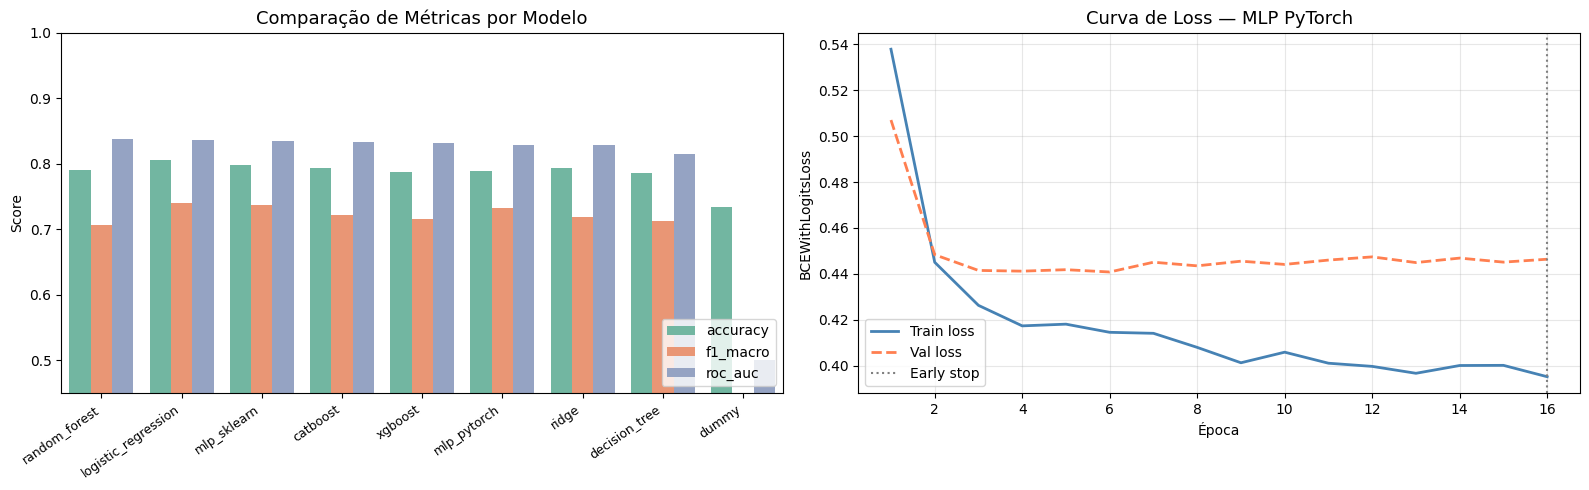

Gráfico salvo em c:\Users\cecil\Tech-challenge-step-1\Tech-challenge-step-1\src\docs\etapa2_comparativo.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Barplot métricas por modelo
metric_cols = [c for c in ["accuracy", "f1_macro", "roc_auc"] if c in df_results.columns]
df_melt = df_results[metric_cols].reset_index().melt(id_vars="index", var_name="Métrica", value_name="Score")
df_melt.rename(columns={"index": "Modelo"}, inplace=True)

sns.barplot(data=df_melt, x="Modelo", y="Score", hue="Métrica", palette="Set2", ax=axes[0])
axes[0].set_title("Comparação de Métricas por Modelo", fontsize=13)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha="right", fontsize=9)
axes[0].set_ylim(0.45, 1.0)
axes[0].set_xlabel("")
axes[0].legend(loc="lower right")

# ── Curva de loss MLP PyTorch
if RUN_PYTORCH and train_losses:
    epochs_ran = range(1, len(train_losses) + 1)
    val_losses_list = [v for _, _, v in train_losses_log]
    axes[1].plot(epochs_ran, train_losses, color="steelblue", linewidth=2, label="Train loss")
    axes[1].plot(
        range(1, len(val_losses_list) + 1), val_losses_list,
        color="coral", linewidth=2, linestyle="--", label="Val loss"
    )
    axes[1].axvline(metrics_pt["stopped_epoch"], color="grey", linestyle=":", label="Early stop")
    axes[1].set_title("Curva de Loss — MLP PyTorch", fontsize=13)
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("BCEWithLogitsLoss")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

plt.tight_layout()
out_path = ROOT / "src" / "docs" / "etapa2_comparativo.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo em {out_path}")

## 8. Matriz de confusão — MLP PyTorch

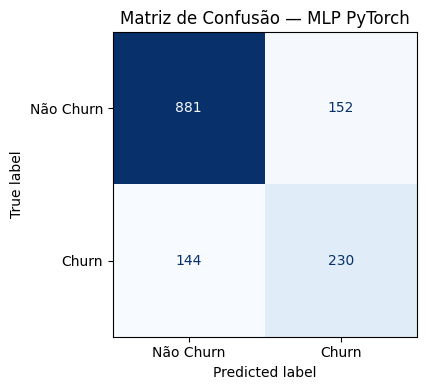

TP=230 | FP=152 | TN=881 | FN=144


In [9]:
if RUN_PYTORCH:
    import torch
    model_pt.eval()
    with torch.no_grad():
        X_te_t = torch.tensor(X_test, dtype=torch.float32)
        logits = model_pt(X_te_t.to(pt_trainer.device)).cpu()
        y_prob_pt = torch.sigmoid(logits).numpy()
        y_pred_pt = (y_prob_pt >= 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred_pt)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=["Não Churn", "Churn"]).plot(
        cmap="Blues", ax=ax, colorbar=False
    )
    ax.set_title("Matriz de Confusão — MLP PyTorch", fontsize=12)
    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f"TP={tp} | FP={fp} | TN={tn} | FN={fn}")

## 9. Análise de custo — Trade-off FP vs FN

No contexto de churn:
- **Falso Negativo (FN)**: cliente vai churnar, mas o modelo não detectou → **custo alto** (receita perdida)
- **Falso Positivo (FP)**: cliente não vai churnar, mas o modelo acha que vai → **custo médio** (oferta de retenção desnecessária)

Parâmetros de custo são exemplificativos (ajuste com valores reais do negócio).

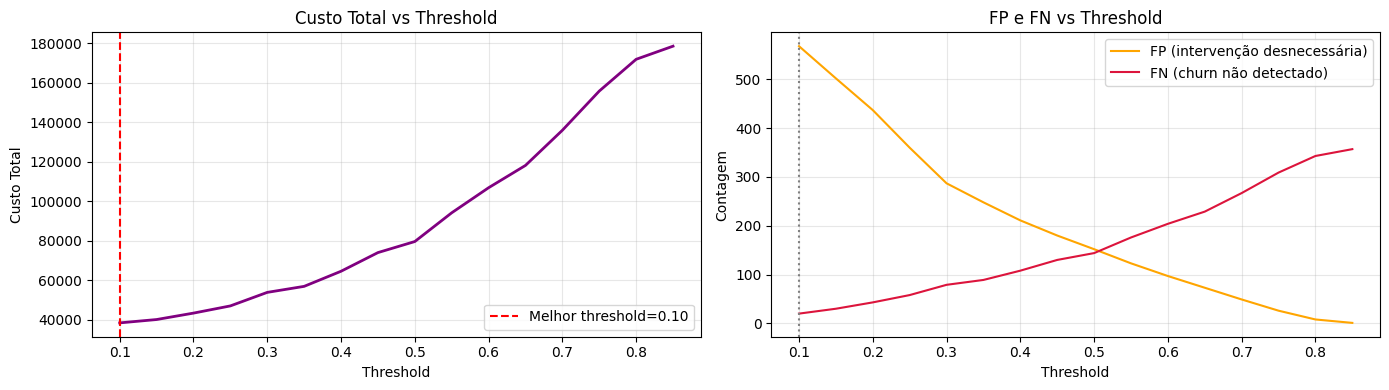


Melhor threshold por custo de negócio : 0.10
  FP=568 × R$50 + FN=20 × R$500 = R$38400


In [10]:
# Custo por tipo de erro (unidades monetárias arbitrárias)
COST_FN = 500   # receita mensal perdida por cliente que churna sem ser retido
COST_FP = 50    # custo da oferta de retenção para cliente que ficaria de qualquer forma

# Variamos o threshold de decisão
thresholds = np.arange(0.1, 0.9, 0.05)
costs = []

if RUN_PYTORCH:
    for t in thresholds:
        y_pred_t = (y_prob_pt >= t).astype(int)
        cm_t = confusion_matrix(y_test, y_pred_t)
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
        total_cost = fp_t * COST_FP + fn_t * COST_FN
        costs.append({"threshold": t, "FP": fp_t, "FN": fn_t, "total_cost": total_cost})

    df_cost = pd.DataFrame(costs)
    best_threshold = df_cost.loc[df_cost["total_cost"].idxmin(), "threshold"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(df_cost["threshold"], df_cost["total_cost"], color="purple", linewidth=2)
    axes[0].axvline(best_threshold, color="red", linestyle="--", label=f"Melhor threshold={best_threshold:.2f}")
    axes[0].set_title("Custo Total vs Threshold")
    axes[0].set_xlabel("Threshold")
    axes[0].set_ylabel("Custo Total")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(df_cost["threshold"], df_cost["FP"], label="FP (intervenção desnecessária)", color="orange")
    axes[1].plot(df_cost["threshold"], df_cost["FN"], label="FN (churn não detectado)", color="crimson")
    axes[1].axvline(best_threshold, color="grey", linestyle=":")
    axes[1].set_title("FP e FN vs Threshold")
    axes[1].set_xlabel("Threshold")
    axes[1].set_ylabel("Contagem")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nMelhor threshold por custo de negócio : {best_threshold:.2f}")
    best_row = df_cost.loc[df_cost["total_cost"].idxmin()]
    print(f"  FP={int(best_row['FP'])} × R${COST_FP} + FN={int(best_row['FN'])} × R${COST_FN} = R${int(best_row['total_cost'])}")

## 10. Relatório final e validação cruzada

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Validação cruzada estratificada no melhor baseline (LR)
cat_cols = df.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in df.columns if c != data_cfg.target and c not in cat_cols]

prep = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols),
])
lr_cv = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=1000, random_state=42))])

X_full = df.drop(columns=[data_cfg.target])
y_full = df[data_cfg.target].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(lr_cv, X_full, y_full, cv=cv, scoring="roc_auc")

print(f"LR — Validação cruzada estratificada (5-fold)")
print(f"  ROC-AUC por fold : {cv_auc.round(4)}")
print(f"  Média ± desvio   : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

LR — Validação cruzada estratificada (5-fold)
  ROC-AUC por fold : [0.8474 0.8477 0.8453 0.8446 0.8402]
  Média ± desvio   : 0.8451 ± 0.0027


In [ ]:
print("=" * 65)
print("  RELATÓRIO FINAL — Etapa 2")
print("=" * 65)

num_df = df_results.select_dtypes(include="number")
best_auc_model = num_df["roc_auc"].idxmax() if "roc_auc" in num_df.columns else "N/A"
best_f1_model  = num_df["f1_macro"].idxmax()  if "f1_macro"  in num_df.columns else "N/A"

print(f"  Melhor ROC-AUC : {best_auc_model} ({num_df['roc_auc'].max():.4f})")
print(f"  Melhor F1 macro: {best_f1_model}  ({num_df['f1_macro'].max():.4f})")

if "mlp_pytorch" in results:
    mlp_auc = results["mlp_pytorch"].get("roc_auc", 0)
    baseline_max = num_df.drop(index="mlp_pytorch", errors="ignore")["roc_auc"].max()
    diff = mlp_auc - baseline_max
    status = "✅ MLP supera" if diff > 0 else "⚠️  MLP abaixo de"
    print(f"\n  MLP PyTorch AUC : {mlp_auc:.4f}")
    print(f"  {status} o melhor baseline por {abs(diff):.4f} de AUC")
    print(f"  Early stopping na época {results['mlp_pytorch'].get('stopped_epoch', '?')}")

print(f"\n  Experimento MLflow : {mlflow_cfg.experiment_name}")
print(f"  Tracking URI       : {mlflow_cfg.tracking_uri}")
print("=" * 65)
print("\n  Para visualizar o MLflow UI, execute:")
print(f"  mlflow ui --backend-store-uri {mlflow_cfg.tracking_uri} --port 5000")
print("  → Abra http://localhost:5000")

  RELATÓRIO FINAL — Etapa 2
  Melhor ROC-AUC : random_forest (0.8384)
  Melhor F1 macro: logistic_regression  (0.7405)

  MLP PyTorch AUC : 0.8291
  ⚠️  MLP abaixo de o melhor baseline por 0.0093 de AUC
  Early stopping na época 16

  Experimento MLflow : telco-churn-etapa2
  Tracking URI       : sqlite:///mlruns.db

  Para visualizar o MLflow UI, execute:
  mlflow ui --backend-store-uri sqlite:///mlruns.db --port 5000
  → Abra http://localhost:5000


: 